# Fitting the landscape model to human scRNA-seq
*Condition: 18h Tgfβ delay*

<br>

In this notebook, we simulate and fit the global landscape model in [1] to the scRNA-seq from days D3 to D7 obtained from human embryonic stem cells [2]. The latter study contains data from conditions that produce different proportions of notochord cells, achieved by altering the duration of the transforming growth factor-$\beta$ (TGF$\beta$) signalling with a 24h delay producing more notochord cells than a 18h delay. Here we use the data for the **18h-Delay** condition.

The simulation and fitting procedures are detailed in Appendix B (Modelling & estimation) [3] of [1]:

* __Section B3:__ Parameterising and simulating the landscape,
* __Section B4:__ Fitting the model to simulated proportions,
* __Section B9:__ Model Parameters fit to the human dataset *(done in this notebook)*.

The fitting machinery is in `fitting_core.py`, the landscape model in `landscape_human.py`, and the plotting helpers in `fitting_plots.py`.

[1] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Dynamic Landscape Analysis of Cell Fate Decisions: Predictive Models of Neural Development From Single-Cell Data*. bioR$\chi$iv doi: https://doi.org/10.1101/2025.05.28.656648.

[2] Rito T., Libby A.R.G, Demuth M., Domart M.-C, Cornwall-Scoones J., Briscoe J. (2025). *Timely tgf$\beta$ signalling inhibition induces notochord formation from human pluripotent stem cells*. Nature 637. https://doi.org/10.1038/s41586-024-08332-w.

[3] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Appendix B: Modelling & estimation*. figshare doi: https://doi.org/10.6084/m9.figshare.31342816.

---
<sub>Author: Marine Fontaine (Warwick)</sub>

### **1.** Load packages

In [3]:
import os
import sys
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **2.** Import experimental proportions

In [56]:
wd = 'Experimental_and_Simulated_Proportions_Human/'  # relative to this notebook

adata = pd.read_csv(wd + 'Proportions_Human_18h-Delay.csv')

# Convert DataFrame to numpy array, divide by 100, and round to two decimal places
processed_data = np.round(adata.to_numpy() , 2).flatten()
# Create dictionary with the processed data for Pyabc
data = {'X_2': processed_data}
adata*100


,PreNeural,p0/p1,p2,pMN,DP,EarlyVentral,Early p3,p3,FP,MNDiff
0,93.132643,3.104421,0.188147,0.000000,0.000000,2.445908,0.000000,0.000000,0.000000,0.282220
1,28.248447,13.416149,21.142857,0.745342,0.397516,11.701863,10.459627,0.322981,0.248447,1.242236
2,0.063091,0.063091,8.643533,32.429022,26.309148,0.126183,8.012618,9.085174,9.337539,5.930599


### **3.** Setting up the model

**Setting up the model.** The fitting machinery lives in `fitting_core`; the *model* is the landscape function you pass to it. The cell below brings the pieces together:

- **`compute_landscape`** (from a `landscape_*` module) — the model itself: the drift + noise of the landscape at each point. Pass a different one (or your own `@njit` function) to fit a different model.
- **`cellstates`** — the approximated attractor positions (one `[x, y]` per state; approximate because an attractor can move when the parameters change). Cells within `radius` of a cellstate are counted as that state when computing proportions.
- **`parSDE`** — the SDE settings (time step, total time, number of cells, measurement times); taken from the landscape's `default_parSDE`.
- **`start_centers` / `samples`** — the initial condition: where cells start and how many in each cluster. Edit these to start from a different mixture.
- **`make_model(...)`** — builds the PyABC model that simulates the SDE and returns the per-timepoint cluster proportions.
- **`get_idx_remove(states_byDay, [...])` + `make_distance(...)`** — build the PyABC distance, dropping the listed timepoints (here D4 and D6) before comparing simulation to data.

In [62]:
# --- Choosing the model ---
from fitting_core import make_model, make_distance, get_idx_remove
from landscape_human import compute_landscape, default_parSDE

parSDE = default_parSDE

# Attractor positions (same for both human conditions).
cellstates = {
    'PreNeural':   [-0.0497558, 4.85763],
    'p0/p1':       [-1.37061, 2.8106],
    'p2':          [-1.84471, 1.1],
    'pMN':         [-2.56928, 0.0889825],
    'DP':          [-1.17209, 0.13729],
    'EarlyVentral':[1.37061, 2.8106],
    'Earlyp3':     [1.70351, 0.457739],
    'p3':          [0.0443102, -0.34472],
    'FP':          [1.83068, -1.3856],
    'MNDiff':      [-3.34239, -0.520129],
}

# Initial condition for the 18h-delay condition: a mixture of start clusters.
# Edit the percentages to change the mixture (must sum to 100%).
start_centers = [(-0.0497558, 4.85763), (1.37061, 2.8106), (-1.37061, 2.8106)]  # PreNeural, EarlyVentral, p0/p1
samples = [int(93*parSDE['ncells']/100), int(3*parSDE['ncells']/100), int(4*parSDE['ncells']/100)]

# Human model drops the intermediate timepoints D4 and D6 before comparing.
model = make_model(compute_landscape, cellstates, parSDE,
                   samples=samples, start_centers=start_centers, radius=0.65)
# Timepoints simulated, and which to drop before comparing to data.
days = ['D3','D4','D5','D6','D7']      # all timepoints the SDE records
drop = ['D4','D6']      # timepoints/states excluded from the fit (and from the comparison below)
states_byDay = [f'{s}-{d}' for d in days for s in cellstates]
distance = make_distance(get_idx_remove(states_byDay, list(cellstates), days, drop))

### **4.** ABC Fitting

To fit the model we use the PyABC package developed for Python in [4,5].
The procedure begins by defining priors distributions for the parameters $\mathbf{p}$ comprising the sub-landscapes parameters $\boldsymbol{\theta}_i=(u_i, v_i)$ for $i=2,\dots, 6$, the scaling parameters $vel_A, vel_B, vel_C$ and the noise parameters $\sigma_A, \sigma_B, \sigma_C, \sigma_D$ (see [3] Appendix B Sections B3 and B9). In our case the priors are taken as uniform distributions supported in the parameter domain $D$ of the stochastic differential equation. Here we use a sampling population of $N=1500$ and a maximal number of 8 generations. See Appendix B Sections B4 (Fitting the model to simulated proportions) and B9 in [3] for details.

[4] Schälte, Y. and Klinger, E. and Alamoudi, E. and Hasenauer, J., (2022). *pyABC: Efficient and robust easy-to-use approximate Bayesian computation*. Journal of Open Source Software, 7(74), 4304, https://doi.org/10.21105/joss.04304.

[5] E. Klinger, D. Rickert, and J. Hasenauer, (2018). *pyABC: distributed, likelihood-free inference*. Bioinformatics, 34(20). https://doi.org/10.1093/bioinformatics/bty361.

In [64]:
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition, MedianEpsilon
from pyabc.visualization import plot_kde_matrix

# Create path to store Pyabc history
path = '.../DynamicalLandscapeAnalysis_v2/FittingGlobalModel'
db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), "FittingHuman18hDelay.db")

# Population size (number of accepted particles per ABC generation).
# Defined once here and reused by ABCSMC and process_simulations.
population_size = 1500

# Define priors
limits = dict(
              u2=(-0.6,0.6),
              v2=(-1.8, -1.1),
              noiseA=(0.2, 0.8),
              velA=(0.2,1),
              u3=(10,18),
              v3=(-2, 4),
              velB=(0.2,1),
              noiseB=(0.2, 0.8),
              u4=(-4,0),
              v4=(-6, -2),
              u5=(5.8,7.8),
              v5=(-0.8,0.5),
              noiseC=(0.2, 0.8),
              velC=(0.2,1),
              u6=(4,7),
              v6=(8,12.5),
              noiseD=(0.2, 0.8))
prior = Distribution(**{key: RV("uniform", a, b - a)
for key, (a,b) in limits.items()})

In [66]:
abc = ABCSMC(
    models=model,
    parameter_priors=prior,
    distance_function=distance,
    population_size=population_size,
    transitions=LocalTransition(k_fraction=0.3),
    eps=pyabc.QuantileEpsilon(alpha=0.2),
)

abc.new(db_path, data);


h = abc.run(minimum_epsilon=0.1, max_nr_populations=8)
run_id = h.id
print("Run ID:", run_id)

ABC.Sampler INFO: Parallelize sampling on 12 processes.
ABC.History INFO: Start <ABCSMC id=7, start_time=2025-05-19 18:02:10>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.55000000e+00.
ABC INFO: Accepted: 1500 / 7170 = 2.0921e-01, ESS: 1.5000e+03.
ABC INFO: t: 1, eps: 1.20500000e+00.
ABC INFO: Accepted: 1500 / 10743 = 1.3963e-01, ESS: 6.2956e+02.
ABC INFO: t: 2, eps: 1.01000000e+00.
ABC INFO: Accepted: 1500 / 20351 = 7.3706e-02, ESS: 5.2976e+02.
ABC INFO: t: 3, eps: 8.90000000e-01.
ABC INFO: Accepted: 1500 / 34556 = 4.3408e-02, ESS: 2.2574e+02.
ABC INFO: t: 4, eps: 8.00000000e-01.
ABC INFO: Accepted: 1500 / 55781 = 2.6891e-02, ESS: 4.0881e+02.
ABC INFO: t: 5, eps: 7.30000000e-01.
ABC INFO: Accepted: 1500 / 57335 = 2.6162e-02, ESS: 4.7652e+02.
ABC INFO: t: 6, eps: 6.70000000e-01.
ABC INFO: Accepted: 1500 / 95218 = 1.5753e-02, ESS: 4.0345e+02.
ABC INFO: t: 7, eps: 6.20000000e-01.
ABC INFO: Accepted: 1500 / 181636 = 8.2583e-03, ESS: 4.6322e+02.
ABC INFO: Stop: Maximum numbe

Run ID: 7


#### **4.1** Visualise the posterior parameter distributions

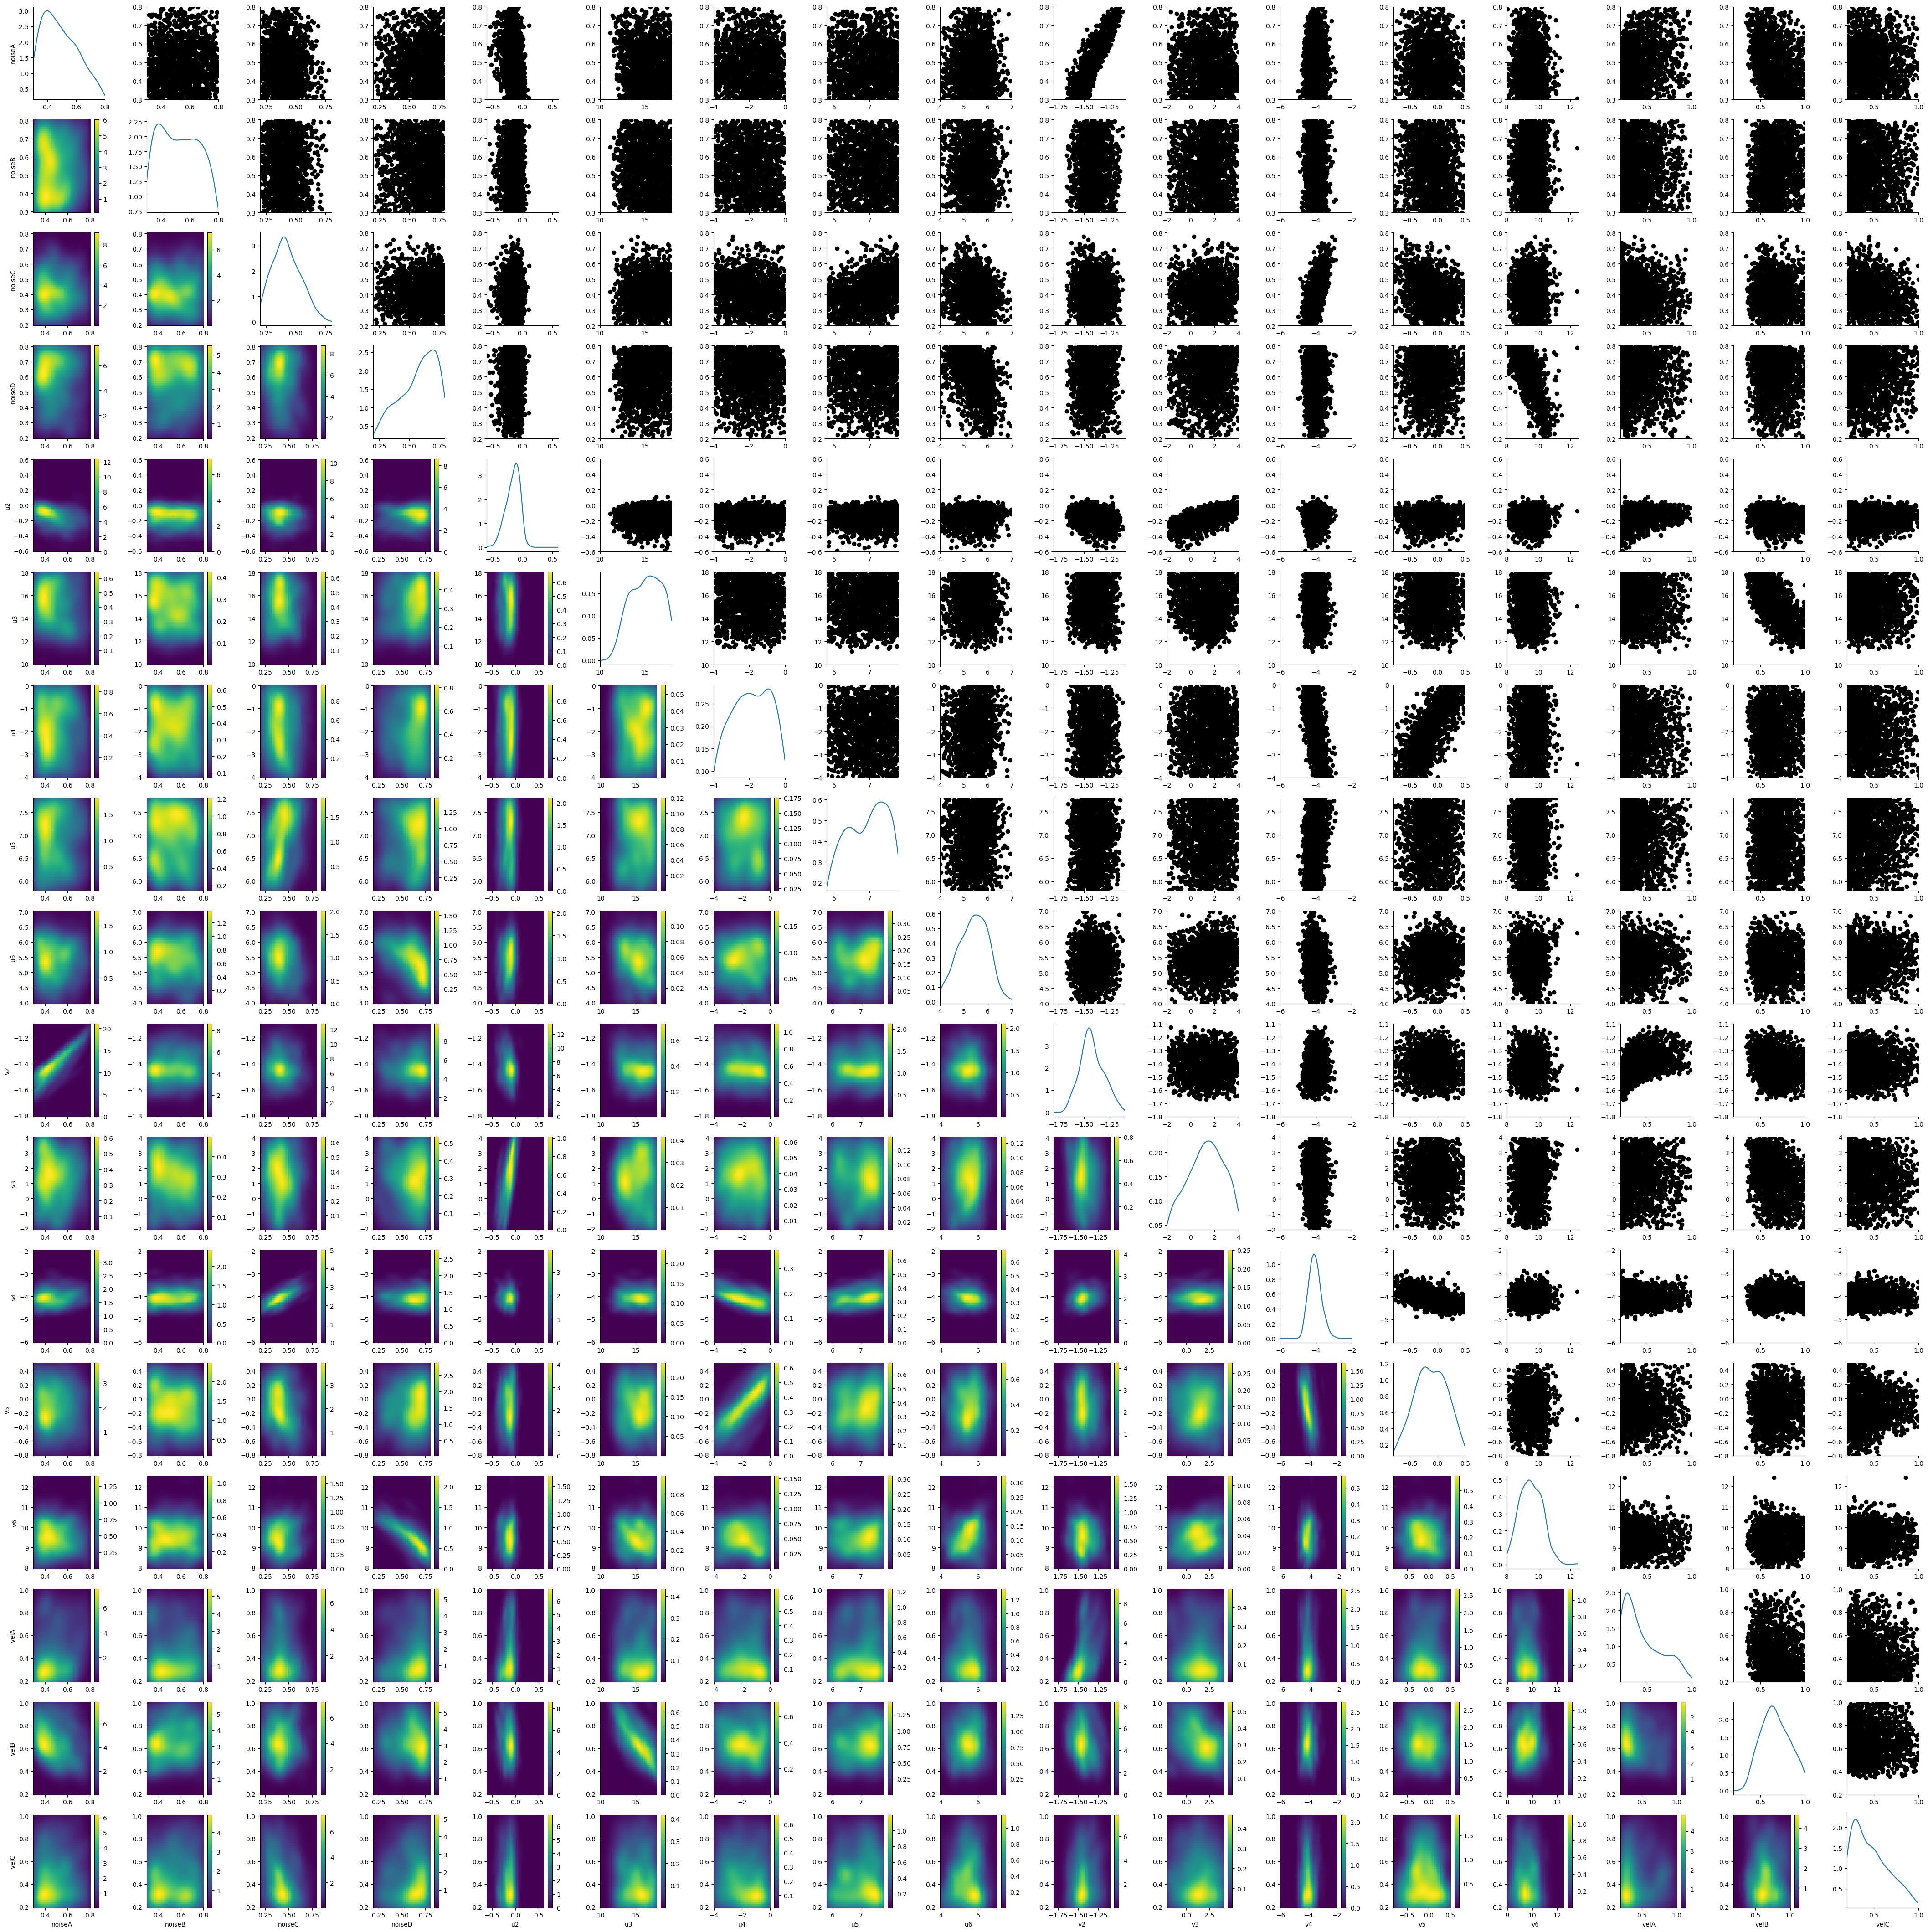

In [69]:
df, w = h.get_distribution(m=0)
plot_kde_matrix(df, w, limits=limits);

#### **4.2** Decrease of the $\varepsilon$-threshold over the 8 generations

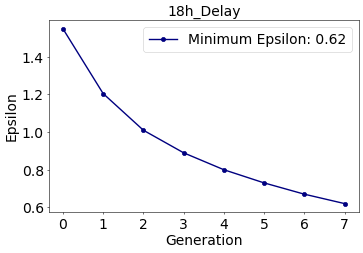

In [72]:
# Given epsilon values and x-axis points
epsilons = h.get_all_populations()["epsilon"].tolist()
epsilons=epsilons[1:]
x_axis = list(range(8)) # 8 is the number of generations

# Create the line plot
plt.figure(figsize=(8, 5),dpi=50)
plt.plot(x_axis, epsilons, marker='o', linestyle='-', color='navy', linewidth=2, 
         label=f"Minimum Epsilon: {min(epsilons):.2f}")

plt.xlabel("Generation", fontsize=20)
plt.ylabel("Epsilon", fontsize=20)
plt.title("18h_Delay", fontsize=20)
plt.legend(loc="upper right", fontsize=20)
plt.grid(False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()


### 4. Compare simulated and experimental proportions

In [75]:
# Import the function to process the simulations (merged module)
from fitting_core import process_simulations, simulation_todf, get_idx_remove
# Import the function to plot the distributions of simulated data
from fitting_plots import plot_data, plot_histogram_grid

# Process simulations
simulation_accepted, dist, simulation_mean = process_simulations(population_size, h, data, parSDE, list(cellstates), idx_remove=get_idx_remove(states_byDay, list(cellstates), days, drop))

#### 4.1 Barplots

In [86]:
# define colors for plot
colorpalette={'PreNeural':'#5D4082',
              'p0/p1':'#122859',
              'p2':'#F9D575',
              'pMN':'#DA2222',
              'DP':'#511A13',
              'EarlyVentral':'#288c9c',
              'Earlyp3':'#CFECE7',
              'p3':'#0D6453',
              'FP':'#000000',
              'MNDiff':'#9F1812'}

The simulation records proportions at **all five** timepoints (`days = ['D3','D4','D5','D6','D7']`), but the fit only used a subset of them — the rest are listed in `drop`. To compare like with like, we keep only the rows of the simulated array whose day is **not** in `drop` (`kept`), rather than slicing by position. This uses the *same* `drop` set defined in the model cell, so the comparison automatically follows whatever timepoints the fit excluded.

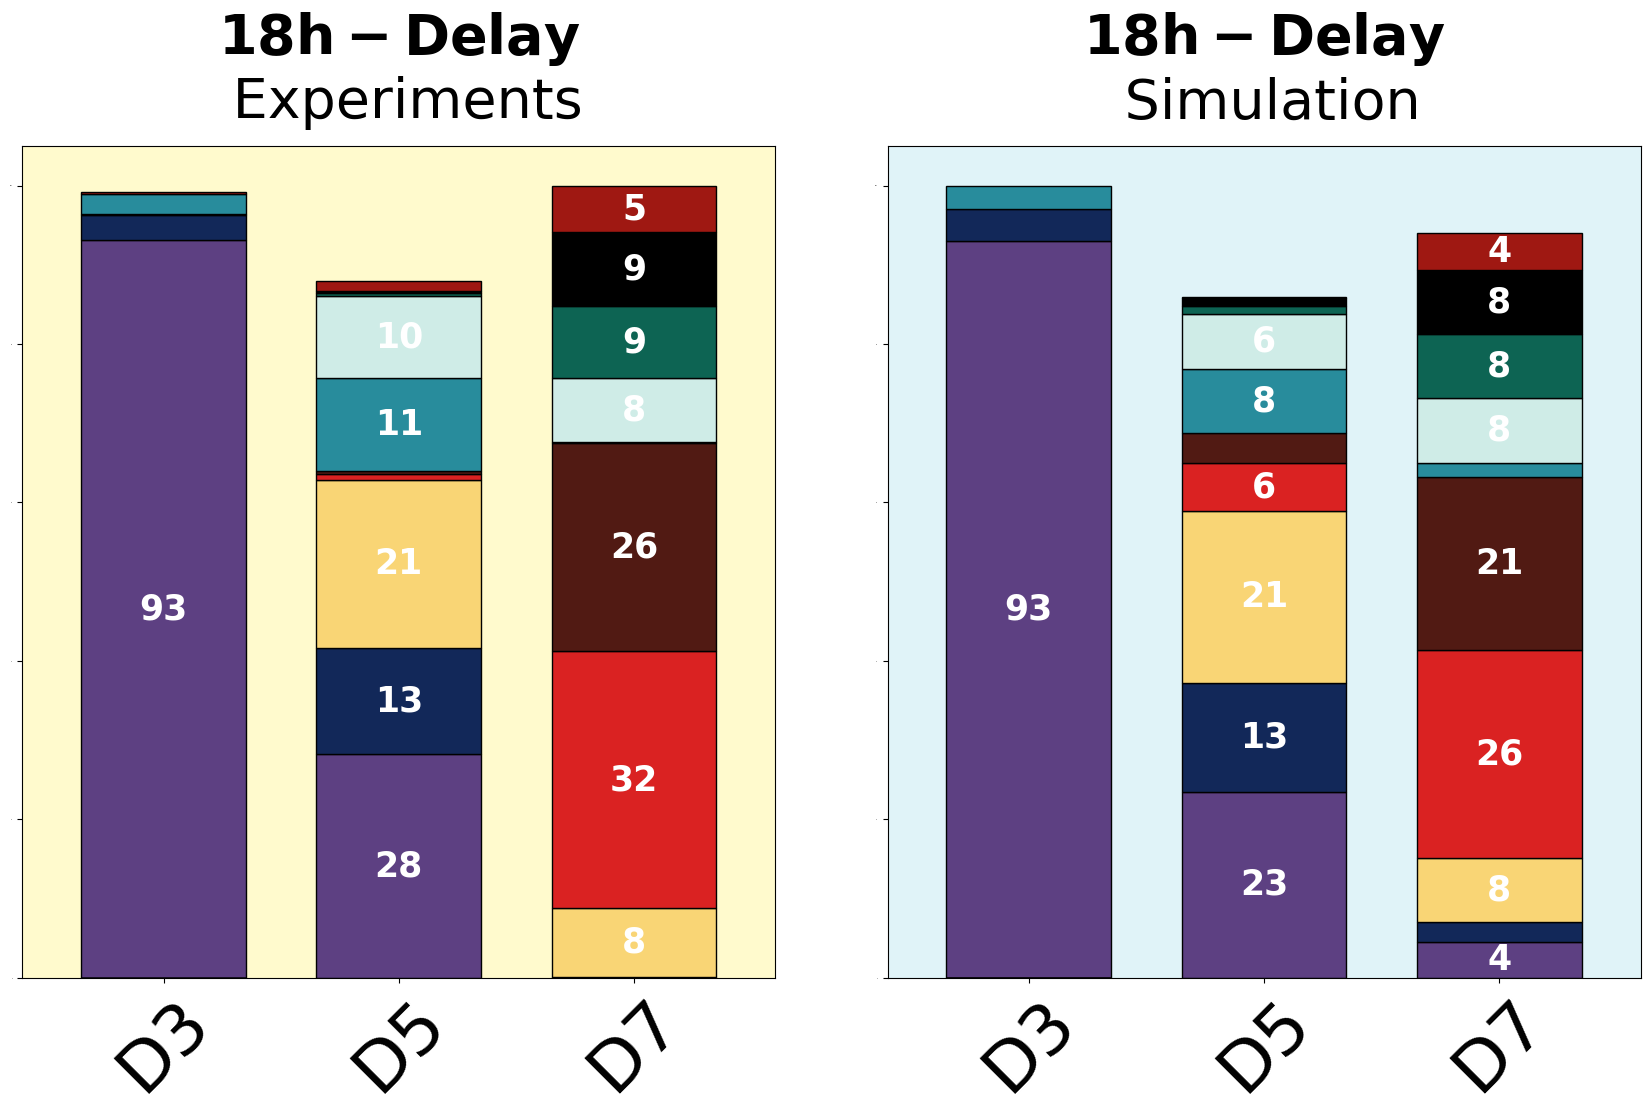

In [100]:
# Usage
states = ['PreNeural','p0/p1','p2','pMN','DP','EarlyVentral','Earlyp3','p3','FP','MNDiff']  # attractor clusters (columns)
# x_labels = the days we actually compare: the simulated `days` minus the dropped ones.
x_labels = [d for d in days if d not in drop]  # timepoints shown

# Reshape simulated means to (day, state) and keep only the compared days.
# `kept` are the row indices of the days NOT in `drop` -- the same drop set used in the fit,
# so we never hard-code which rows to slice.
column_reshaped = simulation_mean.reshape(len(days), len(states))
kept = [i for i, d in enumerate(days) if d not in drop]
simulated_data = pd.DataFrame(column_reshaped[kept], columns=states)

# Experimental proportions for the same days.
data18hDelay = pd.DataFrame(adata.values.reshape(len(x_labels), len(states)), columns=states, index=x_labels)*100  # experimental proportions

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.tight_layout(pad=5)

# barplot of the experimental proportions (average)
plot_data(
    ax=axes[0], 
    data=data18hDelay, 
    title=r'$\bf{18h-Delay}$', 
    x_labels=x_labels, 
    palette=colorpalette, 
    background="data")

# barplot of the simulated proportions (average)
plot_data(
    ax=axes[1], 
    data=simulated_data, 
    title=r'$\bf{18h-Delay}$', 
    x_labels=x_labels, 
    palette=colorpalette, 
    background="simulation")

plt.show()

#### 4.2 Save results

In [103]:
# save simulations
Xsim_df=simulation_todf(states, ['D3','D4','D5','D6','D7'], simulation_accepted)
Xsim_df.to_csv(wd+'RNAseq_Human_18hDelay_simulation.csv', index=False)

# Add distance to experimental data and save parameters
df['distance']=dist
df.to_csv(wd+'RNAseq_Human_18hDelay_parameters.csv', index=False)

# Save probability weights for posterior
#dw=pd.DataFrame(w,columns=['w'])
#dw.to_csv(wd+'RNAseq_Human_18hDelay_weights.csv', index=False)

In [105]:
Xsim_df.head(3)

,PreNeural-D3,p0/p1-D3,p2-D3,pMN-D3,DP-D3,EarlyVentral-D3,Earlyp3-D3,p3-D3,FP-D3,MNDiff-D3,...,PreNeural-D7,p0/p1-D7,p2-D7,pMN-D7,DP-D7,EarlyVentral-D7,Earlyp3-D7,p3-D7,FP-D7,MNDiff-D7
0,0.93,0.04,0.0,0.0,0.0,0.03,0.0,0.0,0.0,0.0,...,0.05,0.02,0.05,0.26,0.27,0.03,0.10,0.05,0.09,0.02
1,0.93,0.04,0.0,0.0,0.0,0.03,0.0,0.0,0.0,0.0,...,0.04,0.04,0.09,0.23,0.26,0.02,0.04,0.09,0.09,0.04
2,0.93,0.04,0.0,0.0,0.0,0.03,0.0,0.0,0.0,0.0,...,0.03,0.00,0.06,0.28,0.22,0.01,0.12,0.09,0.08,0.09


In [107]:
df.head(3)

name,noiseA,noiseB,noiseC,noiseD,u2,u3,u4,u5,u6,v2,v3,v4,v5,v6,velA,velB,velC,distance
id,,,,,,,,,,,,,,,,,,
24008,0.454185,0.507930,0.389247,0.695842,-0.068209,14.520806,-3.349254,7.667519,4.641560,-1.423766,2.272398,-4.056223,-0.552435,8.984778,0.418254,0.748818,0.321002,0.61
24009,0.588492,0.398518,0.496770,0.485101,-0.383316,14.233481,-0.253590,7.050753,5.597093,-1.397055,0.076810,-4.047957,0.181475,10.081135,0.273827,0.671266,0.289849,0.62
24010,0.369982,0.381223,0.437473,0.746776,-0.033639,17.764607,-2.010555,6.729265,4.928714,-1.579593,3.267631,-4.030649,0.008600,8.848038,0.285543,0.715315,0.405065,0.60


#### 4.3  Distributions of the simulated proportions

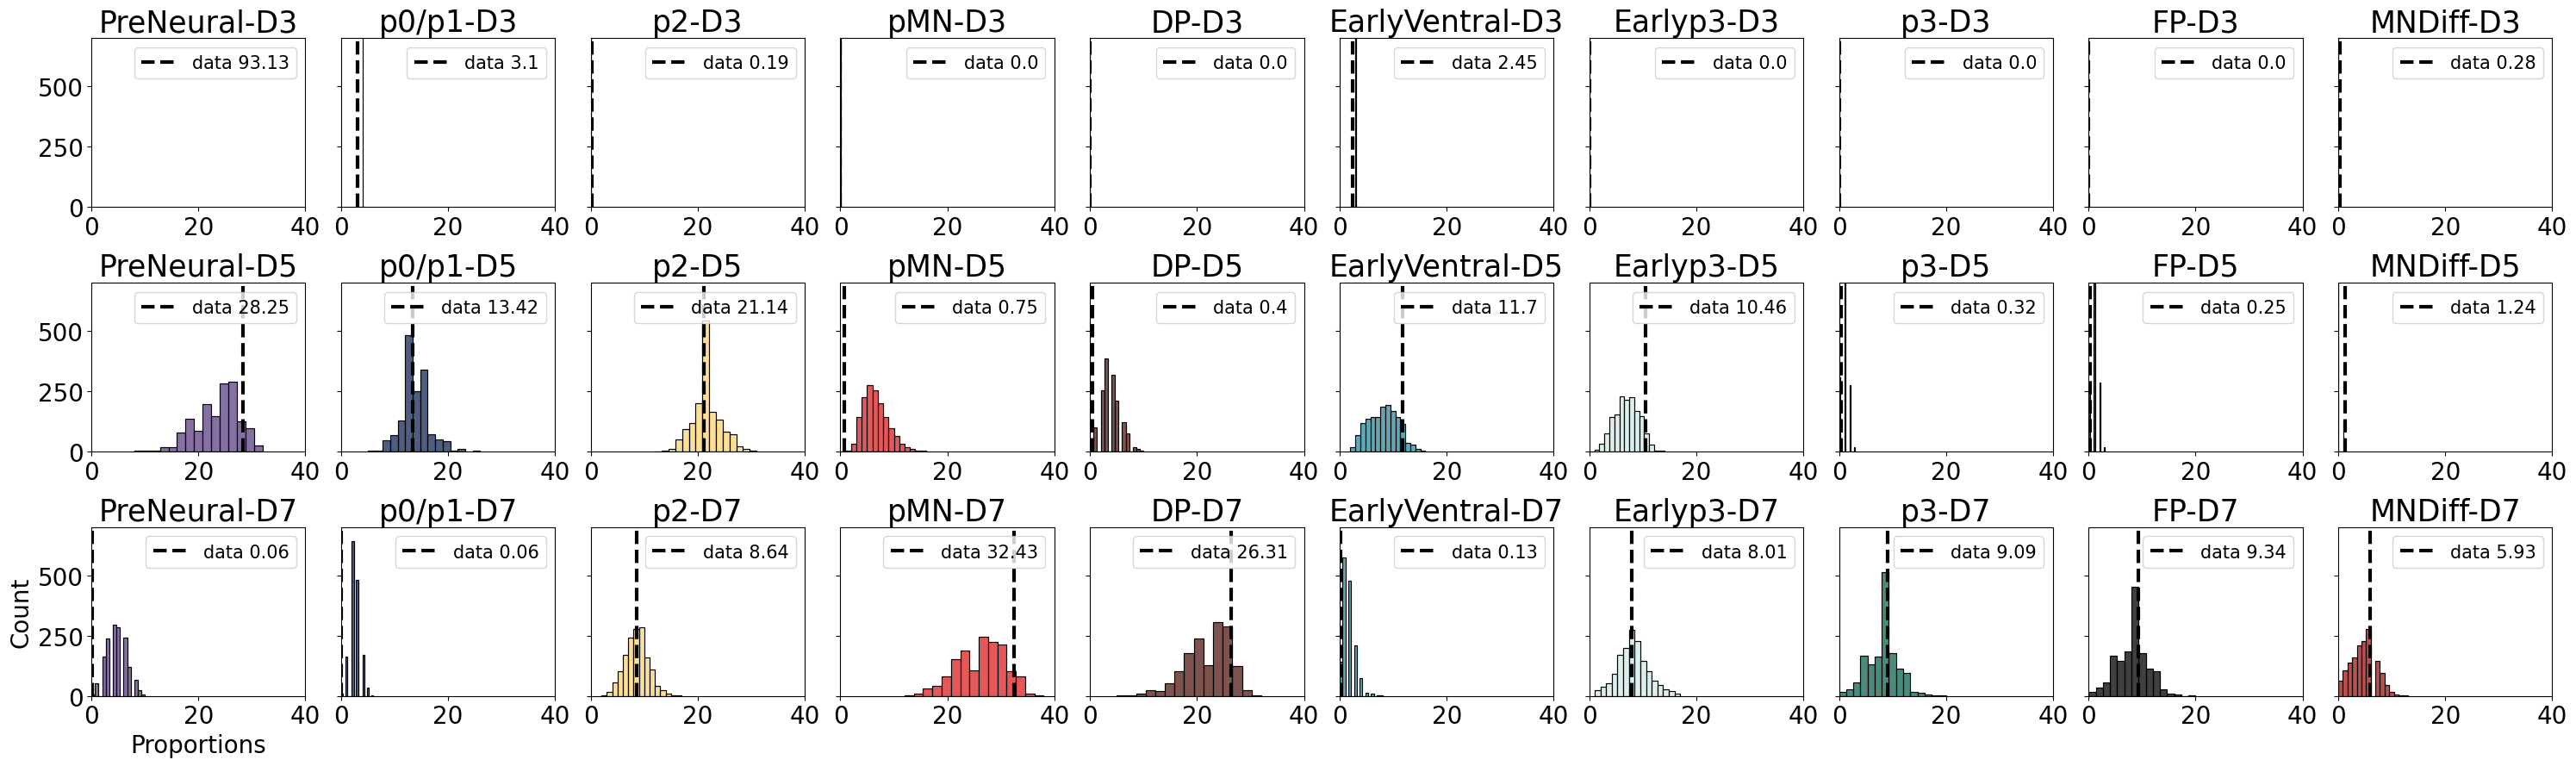

In [110]:
plot_histogram_grid(
    states=states, # attractor clusters
    times=['D3','D5','D7'], # timepoints
    simulation_accepted=Xsim_df, # simulated proportions
    data=data18hDelay, # experimental proportions
    colorpalette=colorpalette, # colors
    bins=15) # number of bins

In [ ]:
# Tendency plot: experimental vs simulation mean per state, with a 5-95 percentile band.
# Uses the same kept timepoints (x_labels) and experimental proportions as the barplot above;
# plot_tendencies selects the matching '<state>-<day>' columns from Xsim_df.
from fitting_plots import plot_tendencies

plot_tendencies(
    states,                 # attractor clusters (one panel each)
    x_labels,               # timepoints shown (kept days)
    Xsim_df[[f'{s}-{d}' for d in x_labels for s in states]],  # simulated proportions for those days/states
    data18hDelay,              # experimental proportions (0-100 scale)
    colorpalette)           # state -> colour
